# 🎬 Movie Recommendation OpenEnv - Interactive Tutorial

This notebook demonstrates how to use the Movie Recommendation OpenEnv environment for training and inference.

**Topics covered:**
1. Environment setup and exploration
2. Simple episode execution
3. Manual recommendation testing
4. Reward analysis
5. Batch user simulation

## 1️⃣ Import Required Libraries and Setup

In [1]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from typing import List, Dict, Tuple

# Import environment
from movie_recommendation_env import (
    MovieRecommendationEnv,
    RecommendationAction,
    MOVIE_DATABASE,
    GENRE_MAPPING,
)

# Setup visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"📊 Total movies in database: {len(MOVIE_DATABASE)}")
print(f"📂 Available genres: {', '.join(GENRE_MAPPING.keys())}")

✅ Libraries imported successfully!
📊 Total movies in database: 15
📂 Available genres: Drama, Action, Comedy, Sci-Fi, Horror, Adventure, Crime, Fantasy, Thriller, Biography, History


## 2️⃣ Load and Explore Movie Dataset

In [2]:
# Create DataFrame from movie database
movies_data = []
for movie_id, movie_info in MOVIE_DATABASE.items():
    movies_data.append({
        'movie_id': movie_id,
        'title': movie_info['title'],
        'genres': ', '.join(movie_info['genres']),
        'year': movie_info['year'],
        'rating': movie_info['rating'],
        'num_genres': len(movie_info['genres']),
    })

movies_df = pd.DataFrame(movies_data)

print("Movie Database Overview:")
print(movies_df.to_string())
print(f"\n📈 Dataset Statistics:")
print(movies_df[['rating', 'year', 'num_genres']].describe())

Movie Database Overview:
     movie_id                                          title                      genres  year  rating  num_genres
0   tt0068646                                  The Godfather                Crime, Drama  1972     9.2           2
1   tt0071562                          The Godfather Part II                Crime, Drama  1974     9.0           2
2   tt0110912                                   Pulp Fiction                Crime, Drama  1994     8.9           2
3   tt0167260  The Lord of the Rings: The Return of the King  Action, Adventure, Fantasy  2003     9.0           3
4   tt0108052                               Schindler's List   Biography, Drama, History  1993     9.0           3
5   tt0468569                                The Dark Knight        Action, Crime, Drama  2008     9.0           3
6   tt0050083                                   12 Angry Men                Crime, Drama  1957     9.0           2
7   tt0816692                                   Interst

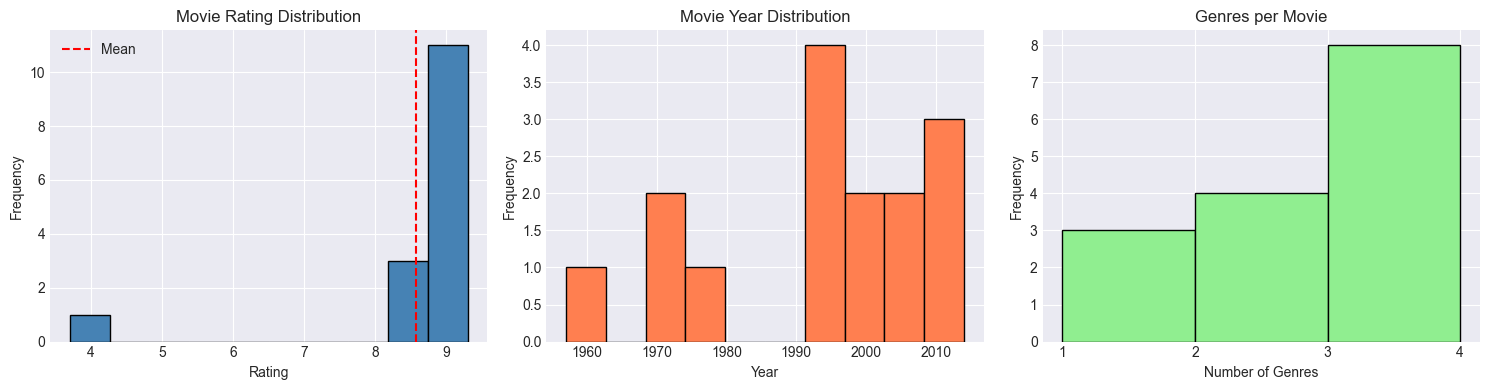


🎬 Top 5 Highest Rated Movies:
                                            title  rating  \
11                       The Shawshank Redemption     9.3   
0                                   The Godfather     9.2   
10                                Game of Thrones     9.2   
1                           The Godfather Part II     9.0   
3   The Lord of the Rings: The Return of the King     9.0   

                        genres  
11                       Drama  
0                 Crime, Drama  
10    Action, Adventure, Drama  
1                 Crime, Drama  
3   Action, Adventure, Fantasy  


In [3]:
# Visualize rating distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
axes[0].hist(movies_df['rating'], bins=10, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Movie Rating Distribution')
axes[0].axvline(movies_df['rating'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Year distribution
axes[1].hist(movies_df['year'], bins=10, color='coral', edgecolor='black')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Movie Year Distribution')

# Genres per movie
axes[2].hist(movies_df['num_genres'], bins=range(1, 5), color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Number of Genres')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Genres per Movie')
axes[2].set_xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()

print(f"\n🎬 Top 5 Highest Rated Movies:")
print(movies_df.nlargest(5, 'rating')[['title', 'rating', 'genres']])

## 3️⃣ Environment Setup and Exploration

In [4]:
# Initialize environment
env = MovieRecommendationEnv(max_recommendations=6)

# Create a sample user profile
user_profile = {
    "name": "Alice",
    "preferred_genres": ["Drama", "Crime"],
    "min_rating": 8.0,
    "avg_rating_tolerance": 1.5,
}

# User's watch history
watch_history = [
    "tt0068646",  # The Godfather
    "tt0110912",  # Pulp Fiction
]

# Reset environment
reset_result = env.reset(user_profile=user_profile, watch_history=watch_history)

print("🎬 Environment Reset Successful!")
print(f"\n📋 User Profile:")
print(f"  Name: {user_profile['name']}")
print(f"  Preferred Genres: {', '.join(user_profile['preferred_genres'])}")
print(f"  Minimum Rating: {user_profile['min_rating']}")
print(f"  Rating Tolerance: ±{user_profile['avg_rating_tolerance']}")
print(f"\n📚 Watch History ({len(watch_history)} movies):")
for movie_id in watch_history:
    movie = MOVIE_DATABASE[movie_id]
    print(f"  - {movie['title']} ({movie['rating']})")

print(f"\n📍 Initial Observation:")
print(f"  Prompt: {reset_result.observation.prompt[:100]}...")
print(f"  Messages: {len(reset_result.observation.messages)}")

🎬 Environment Reset Successful!

📋 User Profile:
  Name: Alice
  Preferred Genres: Drama, Crime
  Minimum Rating: 8.0
  Rating Tolerance: ±1.5

📚 Watch History (2 movies):
  - The Godfather (9.2)
  - Pulp Fiction (8.9)

📍 Initial Observation:
  Prompt: You are an expert movie recommendation agent. Based on the user profile below, recommend movies they...
  Messages: 2


## 4️⃣ Manual Recommendation Testing

In [5]:
# Test recommendations manually
test_recommendations = [
    "tt0111161",  # The Shawshank Redemption (Drama, highly rated)
    "tt0108052",  # Schindler's List (Drama, highly rated)
    "tt0050083",  # 12 Angry Men (Drama, crime-related)
    "tt0816692",  # Interstellar (Sci-Fi, different genre)
    "tt0468569",  # The Dark Knight (Action, crime)
]

results = []
episode_reward = 0

print("🎯 Testing Recommendations:")
print("=" * 80)

for step, movie_id in enumerate(test_recommendations, 1):
    action = RecommendationAction(movie_id=movie_id)
    result = env.step(action)
    
    movie = MOVIE_DATABASE[movie_id]
    reward = result.reward
    episode_reward += reward
    
    results.append({
        'step': step,
        'title': movie['title'],
        'genres': ', '.join(movie['genres']),
        'rating': movie['rating'],
        'reward': reward,
        'error': 'error' in result.info,
    })
    
    print(f"\nStep {step}: {movie['title']}")
    print(f"  Genres: {', '.join(movie['genres'])}")
    print(f"  Rating: {movie['rating']}/10")
    print(f"  Reward: {reward:.3f}")
    
    if 'error' not in result.info:
        breakdown = result.info.get('reward_breakdown', {})
        print(f"  Genre Match: {breakdown.get('genre_match', 0):.3f}")
        print(f"  Quality Score: {breakdown.get('rating_quality', 0):.3f}")
    else:
        print(f"  ❌ Error: {result.info['error']}")

print(f"\n{'='*80}")
print(f"Total Episode Reward: {episode_reward:.3f}")
print(f"Average Reward: {episode_reward/len(test_recommendations):.3f}")

🎯 Testing Recommendations:

Step 1: The Shawshank Redemption
  Genres: Drama
  Rating: 9.3/10
  Reward: 0.506
  Genre Match: 0.500
  Quality Score: 0.930

Step 2: Schindler's List
  Genres: Biography, Drama, History
  Rating: 9.0/10
  Reward: 0.562
  Genre Match: 0.500
  Quality Score: 0.900

Step 3: 12 Angry Men
  Genres: Crime, Drama
  Rating: 9.0/10
  Reward: 0.812
  Genre Match: 1.000
  Quality Score: 0.900

Step 4: Interstellar
  Genres: Adventure, Drama, Sci-Fi
  Rating: 8.7/10
  Reward: 0.619
  Genre Match: 0.500
  Quality Score: 0.870

Step 5: The Dark Knight
  Genres: Action, Crime, Drama
  Rating: 9.0/10
  Reward: 0.812
  Genre Match: 1.000
  Quality Score: 0.900

Total Episode Reward: 3.312
Average Reward: 0.662


## 5️⃣ Reward Analysis and Visualization


📊 Recommendation Results:
 step                    title                    genres  rating  reward  error
    1 The Shawshank Redemption                     Drama     9.3 0.50625  False
    2         Schindler's List Biography, Drama, History     9.0 0.56250  False
    3             12 Angry Men              Crime, Drama     9.0 0.81250  False
    4             Interstellar  Adventure, Drama, Sci-Fi     8.7 0.61875  False
    5          The Dark Knight      Action, Crime, Drama     9.0 0.81250  False


/var/folders/jb/2yhtg48x5zv4vdxrfxd3rjg80000gp/T/ipykernel_7114/890514903.py:55: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/a0s1dpc/miniconda3/envs/neo/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


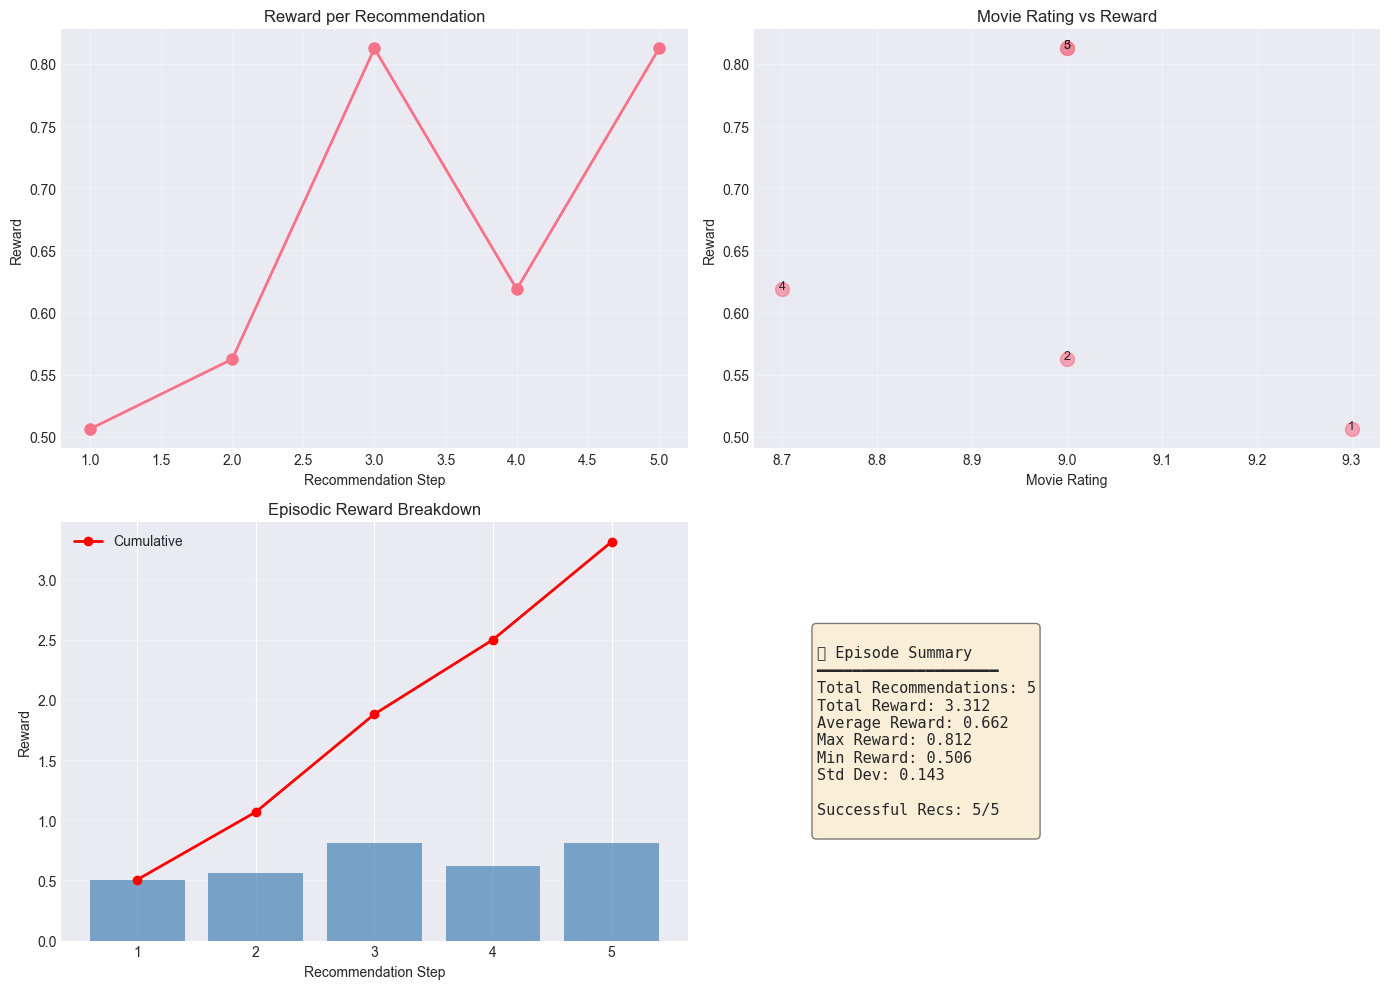

In [6]:
# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n📊 Recommendation Results:")
print(results_df.to_string(index=False))

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reward over steps
axes[0, 0].plot(results_df['step'], results_df['reward'], marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Recommendation Step')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].set_title('Reward per Recommendation')
axes[0, 0].grid(True, alpha=0.3)

# 2. Rating vs Reward
axes[0, 1].scatter(results_df['rating'], results_df['reward'], s=100, alpha=0.6)
for i, row in results_df.iterrows():
    axes[0, 1].annotate(f"{int(row['step'])}", 
                        (row['rating'], row['reward']),
                        fontsize=9, ha='center')
axes[0, 1].set_xlabel('Movie Rating')
axes[0, 1].set_ylabel('Reward')
axes[0, 1].set_title('Movie Rating vs Reward')
axes[0, 1].grid(True, alpha=0.3)

# 3. Cumulative reward
cumulative_reward = results_df['reward'].cumsum()
axes[1, 0].bar(results_df['step'], results_df['reward'], alpha=0.7, color='steelblue')
axes[1, 0].plot(results_df['step'], cumulative_reward, color='red', marker='o', linewidth=2, label='Cumulative')
axes[1, 0].set_xlabel('Recommendation Step')
axes[1, 0].set_ylabel('Reward')
axes[1, 0].set_title('Episodic Reward Breakdown')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Summary statistics
axes[1, 1].axis('off')
summary_text = f"""
📈 Episode Summary
━━━━━━━━━━━━━━━━━━━━
Total Recommendations: {len(results_df)}
Total Reward: {results_df['reward'].sum():.3f}
Average Reward: {results_df['reward'].mean():.3f}
Max Reward: {results_df['reward'].max():.3f}
Min Reward: {results_df['reward'].min():.3f}
Std Dev: {results_df['reward'].std():.3f}

Successful Recs: {(~results_df['error']).sum()}/{len(results_df)}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
               verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 6️⃣ Batch User Simulation

In [7]:
# Simulate multiple users with different preferences
np.random.seed(42)

genre_list = list(GENRE_MAPPING.keys())
num_users = 10

user_results = []

print(f"🎬 Simulating {num_users} users with different preferences...\n")

for user_idx in range(num_users):
    # Create random user profile
    user_env = MovieRecommendationEnv(max_recommendations=3)
    
    user_profile = {
        "name": f"User_{user_idx+1:03d}",
        "preferred_genres": list(np.random.choice(genre_list, 2, replace=False)),
        "min_rating": round(np.random.uniform(6.0, 8.5), 1),
        "avg_rating_tolerance": round(np.random.uniform(0.5, 2.0), 1),
    }
    
    # Reset environment
    reset_result = user_env.reset(user_profile=user_profile)
    
    # Make random valid recommendations
    episode_reward = 0
    num_recs = 0
    
    available_movies = list(MOVIE_DATABASE.keys())
    np.random.shuffle(available_movies)
    
    for movie_id in available_movies[:5]:
        action = RecommendationAction(movie_id=movie_id)
        result = user_env.step(action)
        
        if 'error' not in result.info:
            episode_reward += result.reward
            num_recs += 1
        
        if result.done or num_recs >= 3:
            break
    
    user_results.append({
        'user_id': user_profile['name'],
        'genres': ', '.join(user_profile['preferred_genres']),
        'min_rating': user_profile['min_rating'],
        'num_recommendations': num_recs,
        'total_reward': episode_reward,
        'avg_reward': episode_reward / num_recs if num_recs > 0 else 0,
    })
    
    print(f"{user_profile['name']}: {', '.join(user_profile['preferred_genres'])} | "
          f"Min Rating: {user_profile['min_rating']} | "
          f"Avg Reward: {episode_reward / num_recs if num_recs > 0 else 0:.3f}")
    
    user_env.close()

user_results_df = pd.DataFrame(user_results)
print(f"\n{'='*80}")
print(f"\n📊 Batch Simulation Results:")
print(user_results_df.to_string(index=False))
print(f"\n📈 Aggregate Statistics:")
print(f"  Average Reward Across Users: {user_results_df['avg_reward'].mean():.3f}")
print(f"  Total Recommendations Made: {user_results_df['num_recommendations'].sum()}")

🎬 Simulating 10 users with different preferences...

User_001: Adventure, Drama | Min Rating: 8.2 | Avg Reward: 0.610
User_002: Action, Adventure | Min Rating: 7.7 | Avg Reward: 0.357
User_003: History, Thriller | Min Rating: 7.3 | Avg Reward: 0.389
User_004: Crime, Comedy | Min Rating: 6.7 | Avg Reward: 0.421
User_005: Comedy, Biography | Min Rating: 6.2 | Avg Reward: 0.245
User_006: Horror, Comedy | Min Rating: 6.1 | Avg Reward: 0.243
User_007: Drama, Comedy | Min Rating: 7.3 | Avg Reward: 0.516
User_008: Adventure, Fantasy | Min Rating: 6.8 | Avg Reward: 0.395
User_009: Fantasy, Thriller | Min Rating: 6.4 | Avg Reward: 0.376
User_010: Biography, Action | Min Rating: 6.0 | Avg Reward: 0.490


📊 Batch Simulation Results:
 user_id             genres  min_rating  num_recommendations  total_reward  avg_reward
User_001   Adventure, Drama         8.2                    1      0.610000    0.610000
User_002  Action, Adventure         7.7                    3      1.070000    0.356667
User_00

## 7️⃣ Visualization of Batch Results

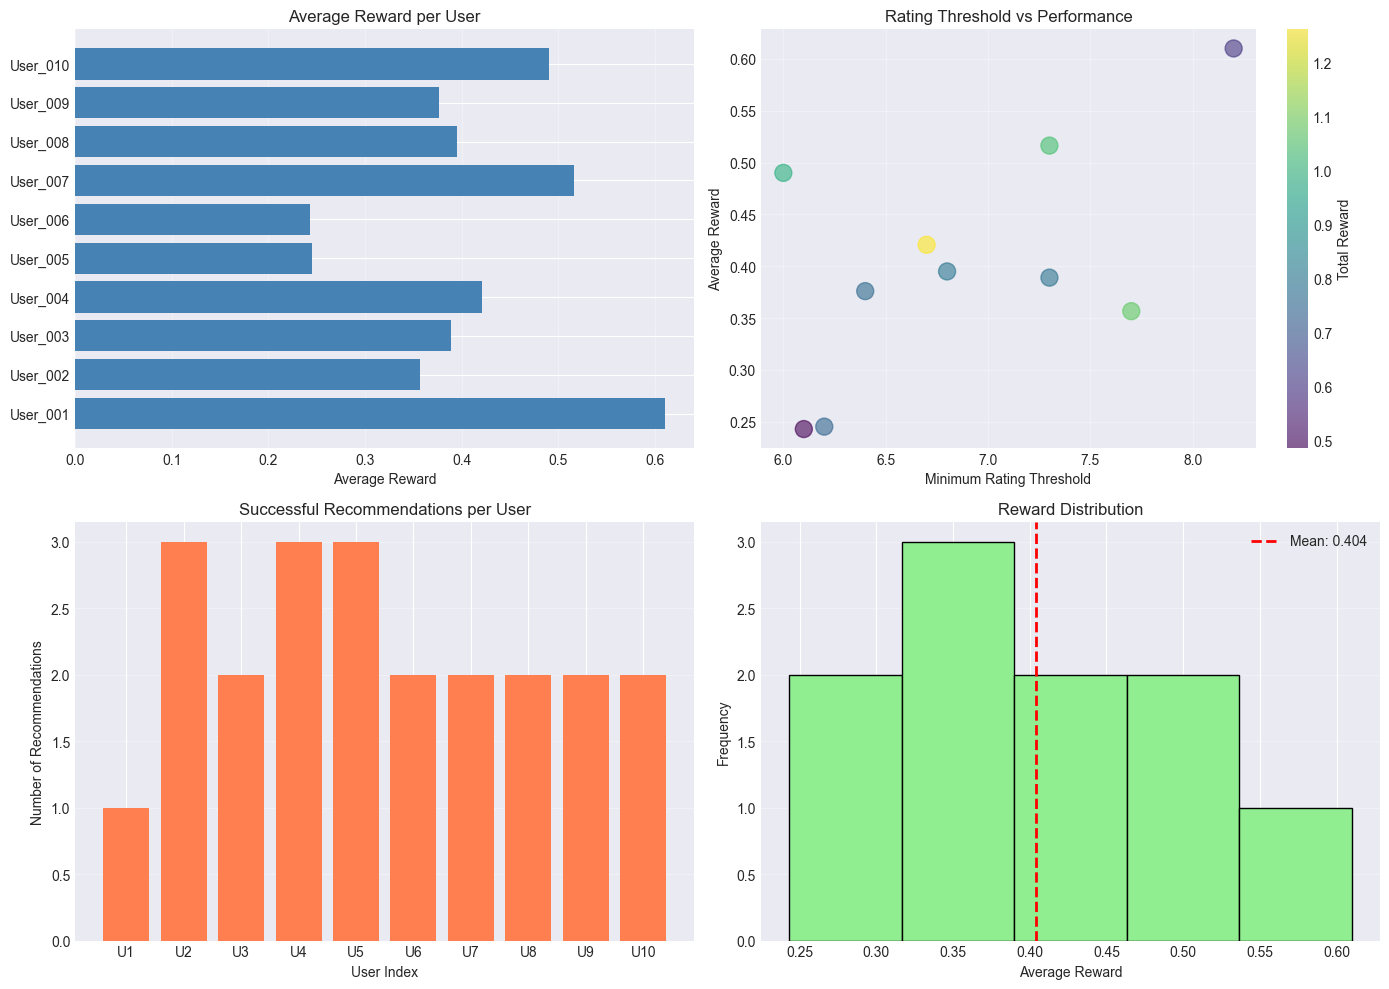

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average reward per user
axes[0, 0].barh(user_results_df['user_id'], user_results_df['avg_reward'], color='steelblue')
axes[0, 0].set_xlabel('Average Reward')
axes[0, 0].set_title('Average Reward per User')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Minimum rating vs average reward
scatter = axes[0, 1].scatter(user_results_df['min_rating'], user_results_df['avg_reward'], 
                             s=150, alpha=0.6, c=user_results_df['total_reward'], cmap='viridis')
axes[0, 1].set_xlabel('Minimum Rating Threshold')
axes[0, 1].set_ylabel('Average Reward')
axes[0, 1].set_title('Rating Threshold vs Performance')
plt.colorbar(scatter, ax=axes[0, 1], label='Total Reward')
axes[0, 1].grid(True, alpha=0.3)

# 3. Number of recommendations
axes[1, 0].bar(range(len(user_results_df)), user_results_df['num_recommendations'], color='coral')
axes[1, 0].set_xlabel('User Index')
axes[1, 0].set_ylabel('Number of Recommendations')
axes[1, 0].set_title('Successful Recommendations per User')
axes[1, 0].set_xticks(range(len(user_results_df)))
axes[1, 0].set_xticklabels([f'U{i+1}' for i in range(len(user_results_df))])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Reward distribution
axes[1, 1].hist(user_results_df['avg_reward'], bins=5, color='lightgreen', edgecolor='black')
axes[1, 1].axvline(user_results_df['avg_reward'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {user_results_df['avg_reward'].mean():.3f}")
axes[1, 1].set_xlabel('Average Reward')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Reward Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8️⃣ Next Steps and Training

### Training a Model with GRPO

To train a model on this environment, use the training script:

```bash
python training.py --model-id Qwen/Qwen3-1.7B --num-epochs 3 --max-users 1000
```

### Running Inference

After training, generate recommendations with:

```bash
python inference.py --model-id path/to/model --user-genres Drama,Crime
```

### Key Hyperparameters

- **Learning Rate**: 5e-6 (smaller for stable training)
- **Batch Size**: 1-4 (depends on GPU memory)
- **Temperature**: 0.8 (exploration vs exploitation)
- **Gradient Accumulation**: 64 (effective batch size)

### Extending the Project

1. Add more movies to `MOVIE_DATABASE`
2. Implement user embeddings for better personalization
3. Add temporal dynamics (trending movies, release dates)
4. Integrate real MovieLens dataset
5. Add collaborative filtering baseline for comparison

### GPU Device Support

The training and inference scripts support multiple devices:

- **Auto-detect** (default): Automatically selects best available device
  ```bash
  python training.py  # Auto-selects CUDA > MPS > CPU
  ```

- **NVIDIA CUDA GPUs**: Standard NVIDIA GPU training
  ```bash
  python training.py --device cuda
  ```

- **Apple Metal (MPS)**: GPU acceleration on Apple Silicon Macs
  ```bash
  python training.py --device mps
  ```

- **CPU**: CPU-only mode (slowest but works everywhere)
  ```bash
  python training.py --device cpu
  ```

#### MPS (Apple Silicon) Optimization Tips

If using MPS on Mac:

1. **Reduce batch size** if you get OOM errors:
   ```bash
   python training.py --device mps --per-device-batch-size 1
   ```

2. **Use smaller models** for better MPS compatibility:
   ```bash
   python training.py --device mps --model-id Qwen/Qwen3-1.7B
   ```

3. **Inference on MPS**:
   ```bash
   python inference.py --device mps --user-genres Drama,Crime
   ```

In [9]:
print("""
🎬 MOVIE RECOMMENDATION OPENENV - TUTORIAL COMPLETE! 🎬
════════════════════════════════════════════════════════

✅ You've learned how to:

   1. Explore the movie database
   2. Create user profiles with preferences
   3. Interact with the OpenEnv environment
   4. Analyze reward signals
   5. Simulate batch user scenarios

📚 Next Steps:

   • Run: python examples_simple.py       # Simple demo
   • Train: python training.py            # GRPO training
   • Infer: python inference.py           # Get recommendations

🔗 Resources:

   • OpenEnv: https://github.com/meta-pytorch/OpenEnv
   • TRL Docs: https://huggingface.co/docs/trl
   • Hackathon: https://scaler.com/school-of-technology/meta-pytorch-hackathon

🎯 Happy coding and good luck with the hackathon!
════════════════════════════════════════════════════════
""")


🎬 MOVIE RECOMMENDATION OPENENV - TUTORIAL COMPLETE! 🎬
════════════════════════════════════════════════════════

✅ You've learned how to:

   1. Explore the movie database
   2. Create user profiles with preferences
   3. Interact with the OpenEnv environment
   4. Analyze reward signals
   5. Simulate batch user scenarios

📚 Next Steps:

   • Run: python examples_simple.py       # Simple demo
   • Train: python training.py            # GRPO training
   • Infer: python inference.py           # Get recommendations

🔗 Resources:

   • OpenEnv: https://github.com/meta-pytorch/OpenEnv
   • TRL Docs: https://huggingface.co/docs/trl
   • Hackathon: https://scaler.com/school-of-technology/meta-pytorch-hackathon

🎯 Happy coding and good luck with the hackathon!
════════════════════════════════════════════════════════



In [10]:
# Check available devices
import torch

print("=" * 60)
print("🖥️  AVAILABLE DEVICES")
print("=" * 60)

print(f"\nPyTorch Version: {torch.__version__}")
print(f"CPU Available: ✅")

# Check CUDA
if torch.cuda.is_available():
    print(f"CUDA Available: ✅")
    print(f"  Device: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")
else:
    print(f"CUDA Available: ❌")

# Check MPS (Apple Metal)
if torch.backends.mps.is_available():
    print(f"MPS (Apple Silicon): ✅")
    if hasattr(torch.backends.mps, 'is_built'):
        print(f"  Built with MPS Support: {torch.backends.mps.is_built()}")
else:
    print(f"MPS (Apple Silicon): ❌")

print("\n" + "=" * 60)
print("🚀 RECOMMENDED DEVICE SELECTION")
print("=" * 60)

if torch.cuda.is_available():
    print("✨ Use: --device cuda  (NVIDIA GPU - fastest)")
elif torch.backends.mps.is_available():
    print("🍎 Use: --device mps   (Apple Silicon - fast)")
else:
    print("💻 Use: --device cpu   (CPU - slower but always works)")

print("=" * 60)

🖥️  AVAILABLE DEVICES

PyTorch Version: 2.10.0
CPU Available: ✅
CUDA Available: ❌
MPS (Apple Silicon): ✅
  Built with MPS Support: True

🚀 RECOMMENDED DEVICE SELECTION
🍎 Use: --device mps   (Apple Silicon - fast)
